Get dataset

In [51]:
from torchvision.transforms import v2
from torch.nn import Sequential, Dropout
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10

batch_size = 100

transform_train = Sequential(
    v2.RandomCrop(32, padding=4),
    v2.RandomHorizontalFlip(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
)

train_set = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)

Check picture size

In [52]:
print(train_set[0][0].shape)

torch.Size([3, 32, 32])


CNN (VGG style)

In [53]:
from torch.nn import Conv2d, MaxPool2d, Linear, ReLU, Flatten, BatchNorm2d

input_dim = 3
output_dim = 10

Conv_block = lambda in_channels: Sequential(
    Conv2d(in_channels, in_channels * 4, kernel_size=3, padding=1),
    ReLU(),
    BatchNorm2d(in_channels * 4),
    MaxPool2d(kernel_size=2),
)

model = Sequential(
    Conv_block(input_dim),  # (12, 16, 16)
    Conv_block(input_dim * 4),  # (48, 8, 8)
    Conv_block(input_dim * 16),  # (192, 4, 4)
    Conv_block(input_dim * 64),  # (768, 2, 2)
    Flatten(),
    Dropout(0.5),
    Linear(input_dim * 256 * 2 * 2, input_dim * 64),
    ReLU(),
    Linear(input_dim * 64, output_dim),
)

Get GPU

In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)
print('Current device :', device)

Current device : cuda


Training

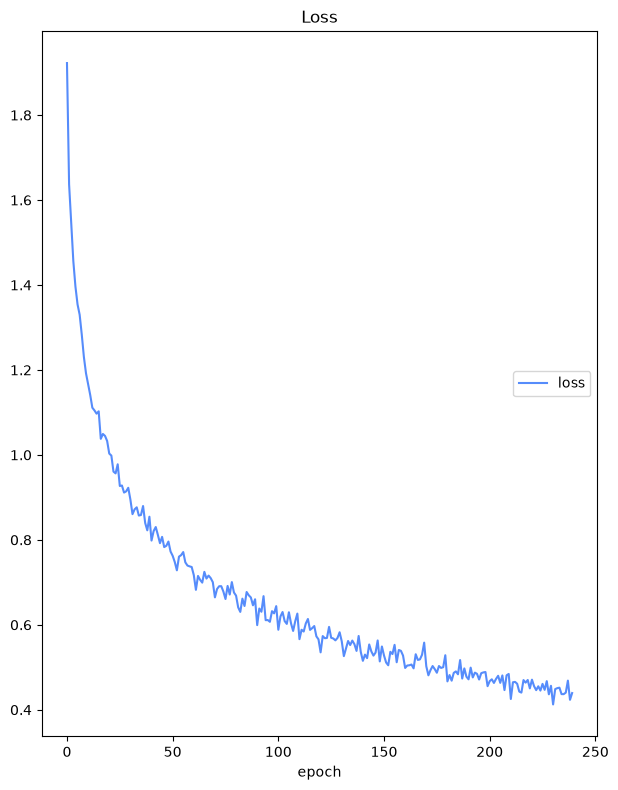

Loss
	loss             	 (min:    0.413, max:    1.922, cur:    0.439)


In [55]:
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from livelossplot import PlotLosses

model.train()

learning_rate = 5e-4
lr_decrease = 0.5
epoch = 0
epoch_loss = 0
print_epoch = 50
round = 24

plotlosses = PlotLosses()
optimizer = AdamW(model.parameters(), lr=learning_rate)
criterion = CrossEntropyLoss()

for i in range(round):
    for data in train_loader:
        input, labels = data
        optimizer.zero_grad()
        loss = criterion(model(input.to(device)), labels.to(device))
        loss.backward()
        optimizer.step()
        epoch += 1
        epoch_loss += loss.item()

        if epoch % print_epoch == 0:
            plotlosses.update({'loss': epoch_loss / print_epoch})
            plotlosses.send()
            epoch_loss = 0
    learning_rate *= lr_decrease


Test dataset

In [56]:
from torchvision.transforms import ToTensor

model.eval()

test_set = CIFAR10(root='./data', train=False, download=True, transform=ToTensor())
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)
total = len(test_set)
correct = 0

with torch.no_grad():
    for input, label in test_loader:
        predicted = model(input.to(device)).argmax(dim=1)
        correct += (predicted == label.to(device)).sum().item()

print('Correct', correct, 'out of', total, 'accuracy:', '{:.2f}%'.format(correct / total * 100))

Correct 8048 out of 10000 accuracy: 80.48%


Result Check

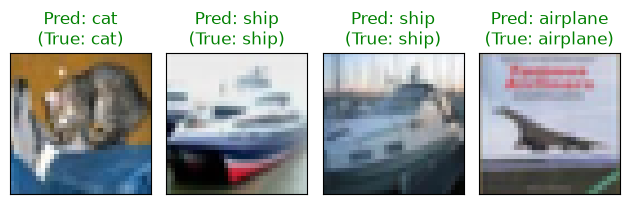

In [57]:
import matplotlib.pyplot as plt
import numpy as np

data_iter = iter(test_loader)
images, labels = next(data_iter)

with torch.no_grad():
    predicted = model(images.to(device)).argmax(dim=1)

fig = plt.figure()
batch_size_to_show = min(len(images), 4)

for idx in range(batch_size_to_show):
    ax = fig.add_subplot(1, batch_size_to_show, idx + 1, xticks=[], yticks=[])
    img = images[idx].numpy().transpose((1, 2, 0))

    img = np.clip(img, 0, 1)

    ax.imshow(img)

    pred_title = test_set.classes[predicted[idx].item()]
    true_title = test_set.classes[labels[idx].item()]

    color = "green" if pred_title == true_title else "red"
    ax.set_title(f"Pred: {pred_title}\n(True: {true_title})", color=color, fontsize=12)

plt.tight_layout()
plt.show()